In [134]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [135]:
df = pd.read_csv("weather_classification_data.csv")

In [136]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [137]:
df.tail()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy
13199,-5.0,38,0.0,92.0,overcast,1015.37,5,Autumn,10.0,mountain,Rainy


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [139]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [140]:
df.shape

(13200, 11)

In [141]:
df.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [143]:
df['Cloud Cover'].unique()

array(['partly cloudy', 'clear', 'overcast', 'cloudy'], dtype=object)

In [144]:
df['Season'].unique()

array(['Winter', 'Spring', 'Summer', 'Autumn'], dtype=object)

In [145]:
df['Location'].unique()

array(['inland', 'mountain', 'coastal'], dtype=object)

In [146]:
num_cols = ['Temperature','Humidity','Wind Speed','Precipitation (%)','Atmospheric Pressure','UV Index','Visibility (km)']

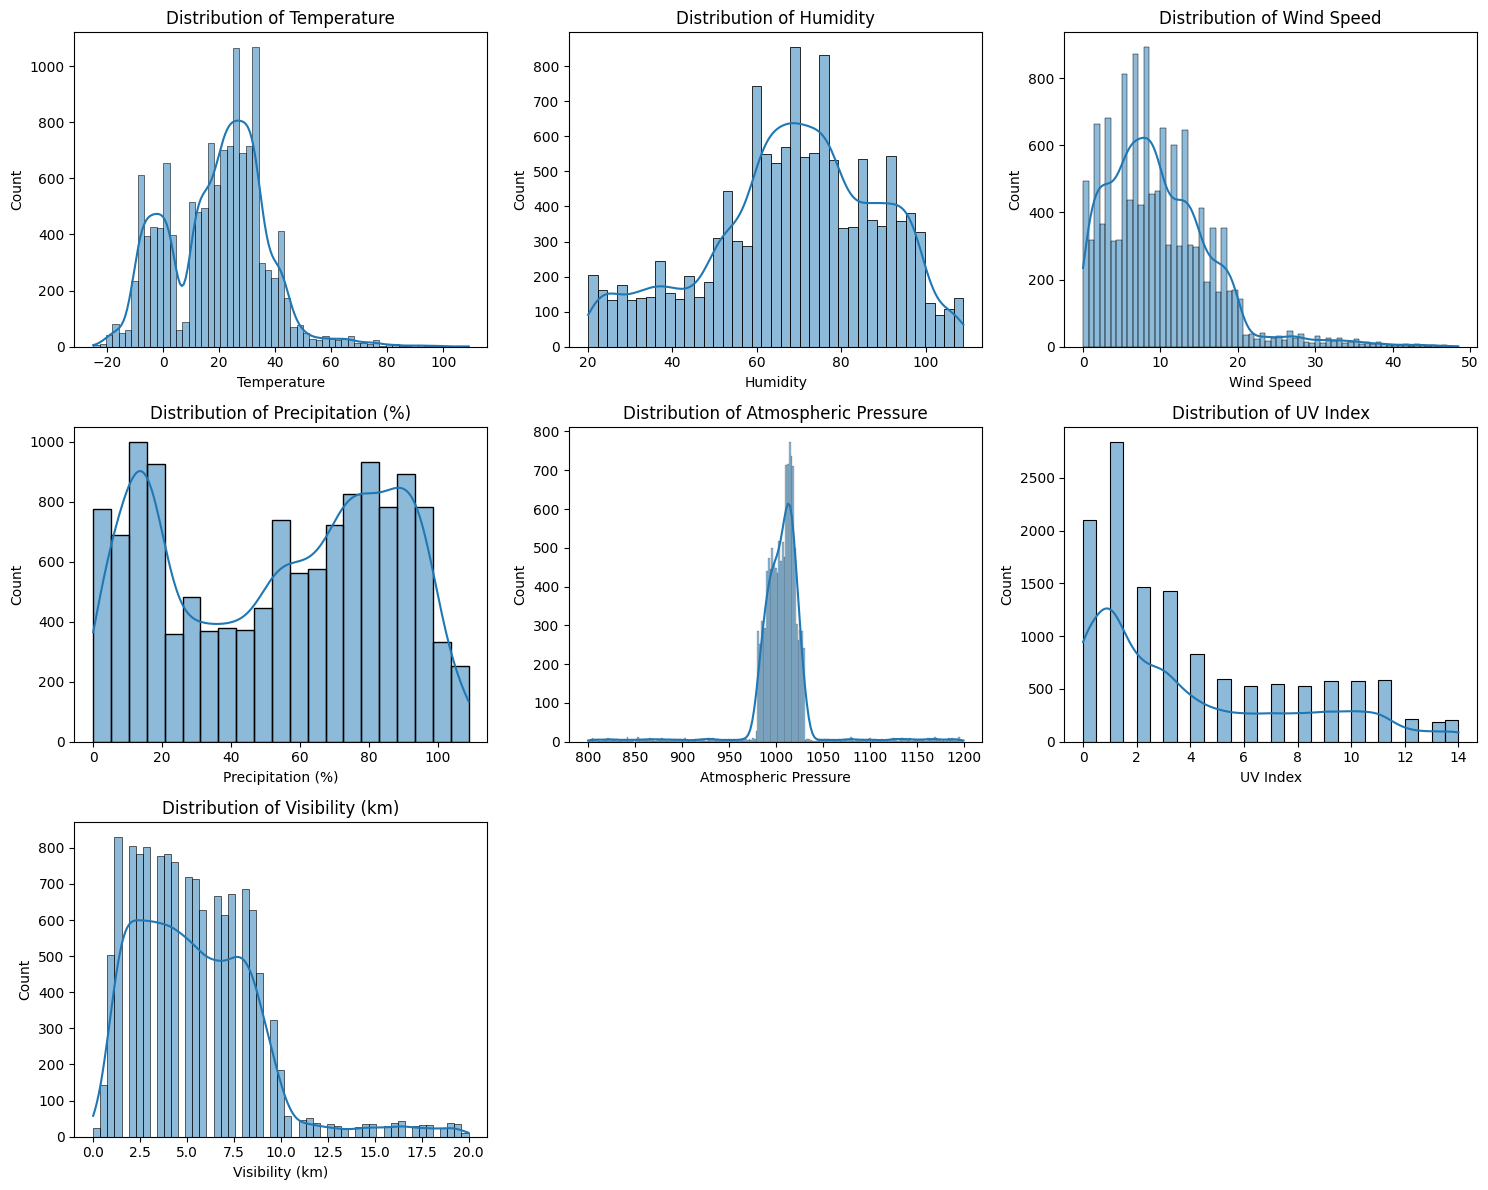

In [147]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()


In [148]:
categorical_cols = ['Cloud Cover', 'Season','Location','Weather Type']

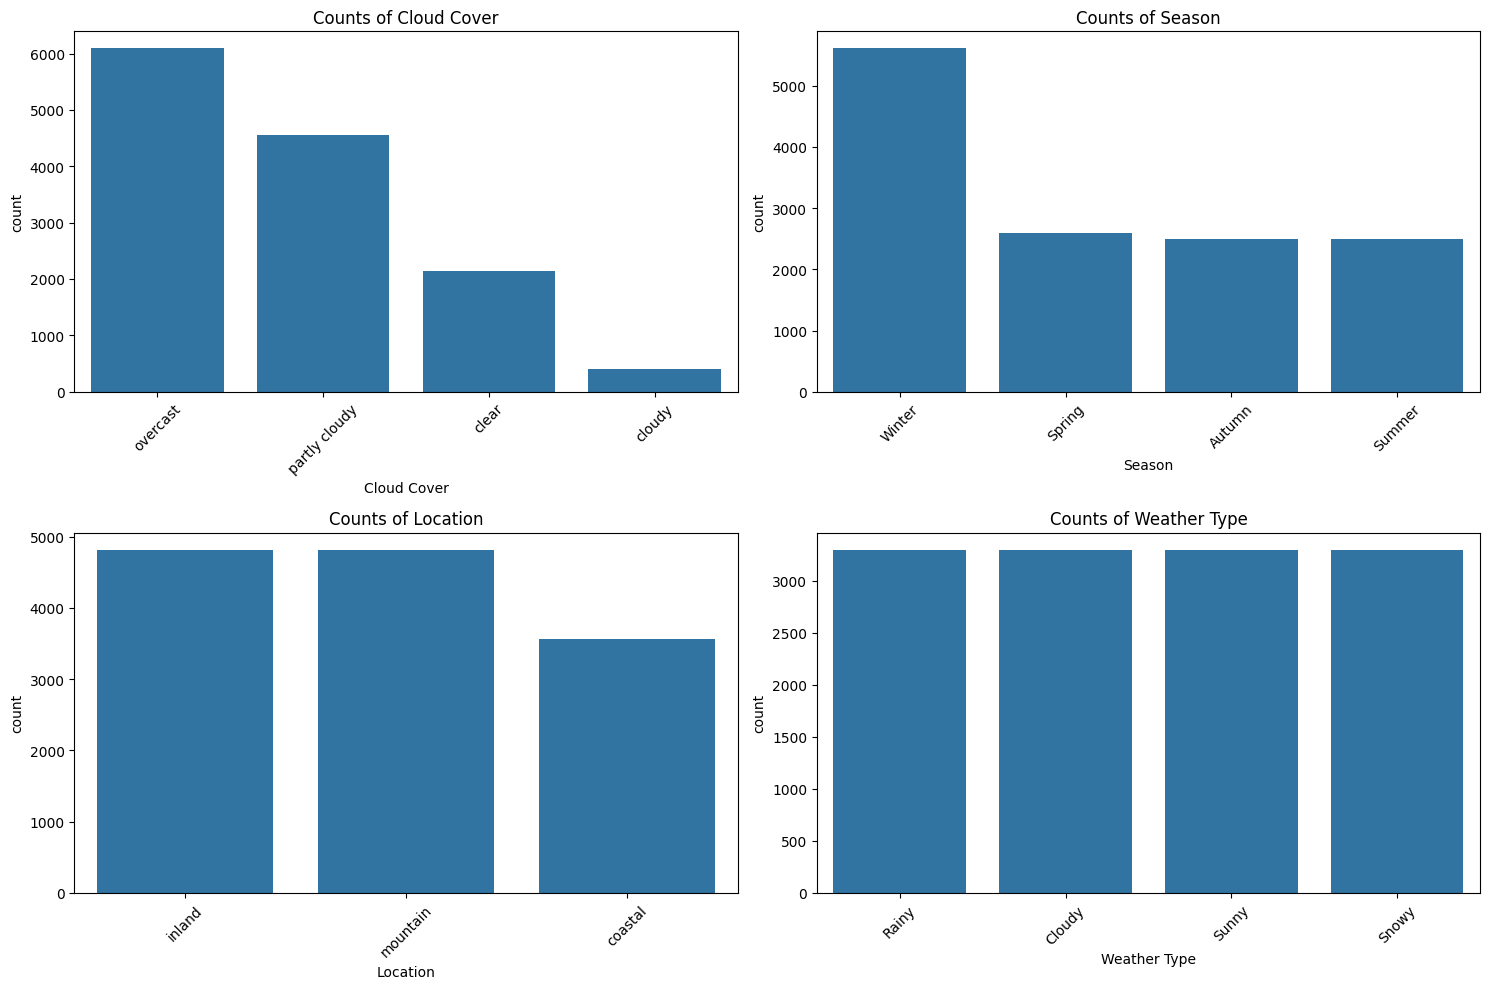

In [149]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i+1)
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f'Counts of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()

In [150]:
num_corr = df[num_cols].corr()

<Axes: >

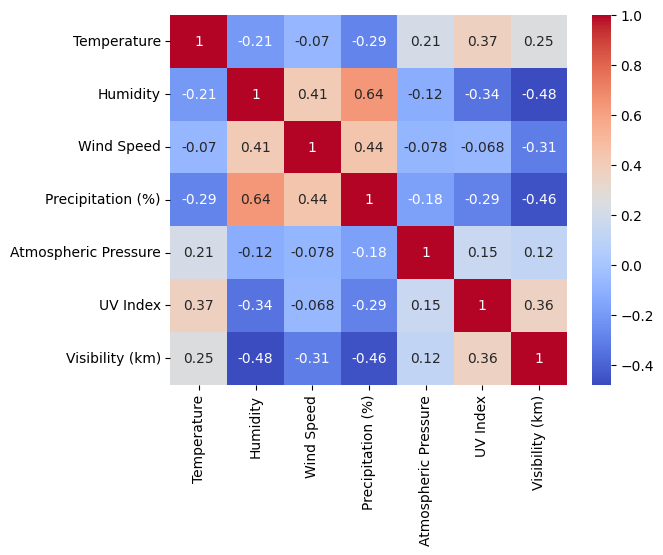

In [151]:
sns.heatmap(num_corr, annot=True, cmap='coolwarm')

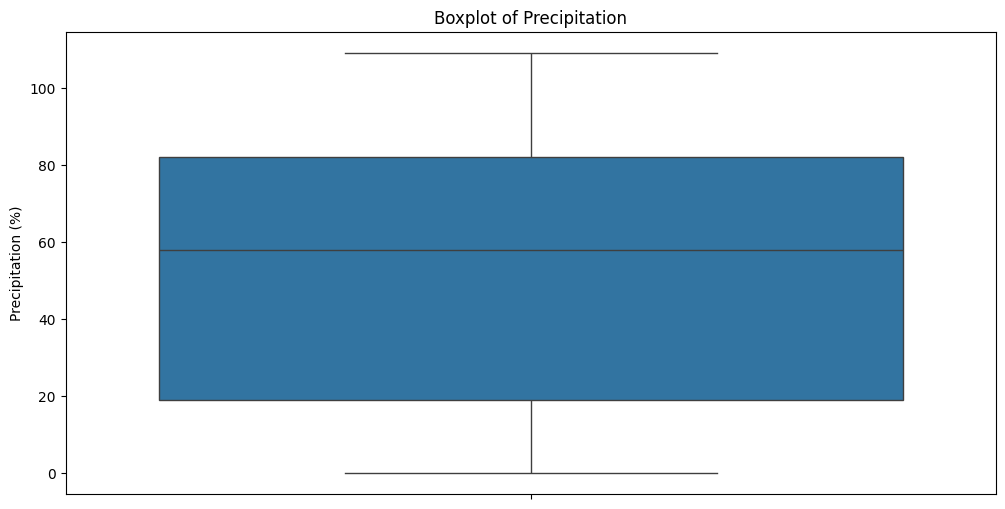

In [152]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df['Precipitation (%)'])
plt.title("Boxplot of Precipitation")
plt.show()

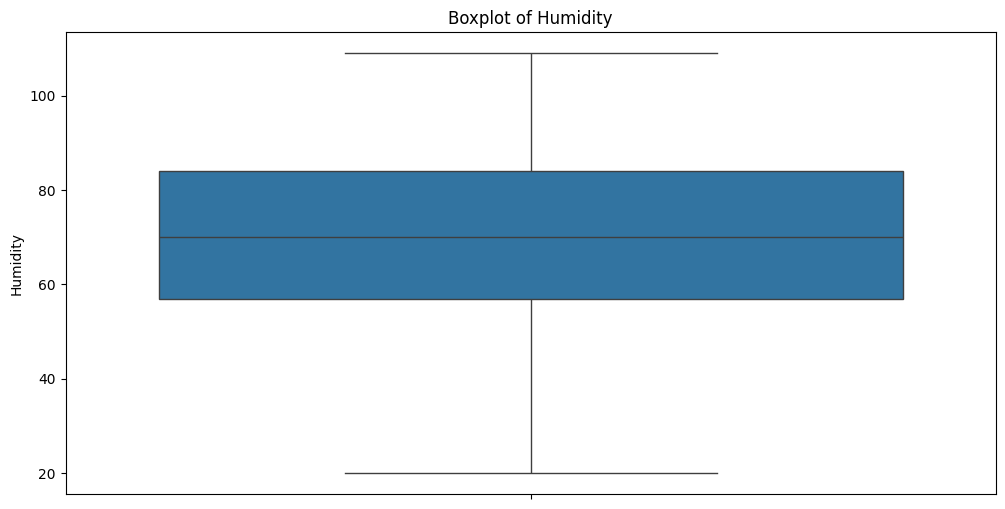

In [153]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df['Humidity'])
plt.title("Boxplot of Humidity")
plt.show()

In [154]:
df.drop(df[df['Precipitation (%)']>100].index, inplace = True)

In [155]:
df.drop(df[df['Humidity']>100].index, inplace = True)

In [156]:
df.shape

(12483, 11)

In [157]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000
mean,18.613074,67.100136,9.394577,51.207562,1005.814698,3.824882,5.532244
std,16.672864,19.383613,6.360919,31.019456,38.134520,3.746314,3.377035
min,-24.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,56.000000,5.000000,19.000000,994.695000,1.000000,3.000000
50%,21.000000,69.000000,8.500000,55.000000,1007.660000,2.000000,5.000000
75%,30.000000,81.000000,13.000000,79.000000,1016.825000,6.000000,7.500000
max,109.000000,100.000000,48.500000,100.000000,1199.210000,14.000000,20.000000


In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12483 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           12483 non-null  float64
 1   Humidity              12483 non-null  int64  
 2   Wind Speed            12483 non-null  float64
 3   Precipitation (%)     12483 non-null  float64
 4   Cloud Cover           12483 non-null  object 
 5   Atmospheric Pressure  12483 non-null  float64
 6   UV Index              12483 non-null  int64  
 7   Season                12483 non-null  object 
 8   Visibility (km)       12483 non-null  float64
 9   Location              12483 non-null  object 
 10  Weather Type          12483 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


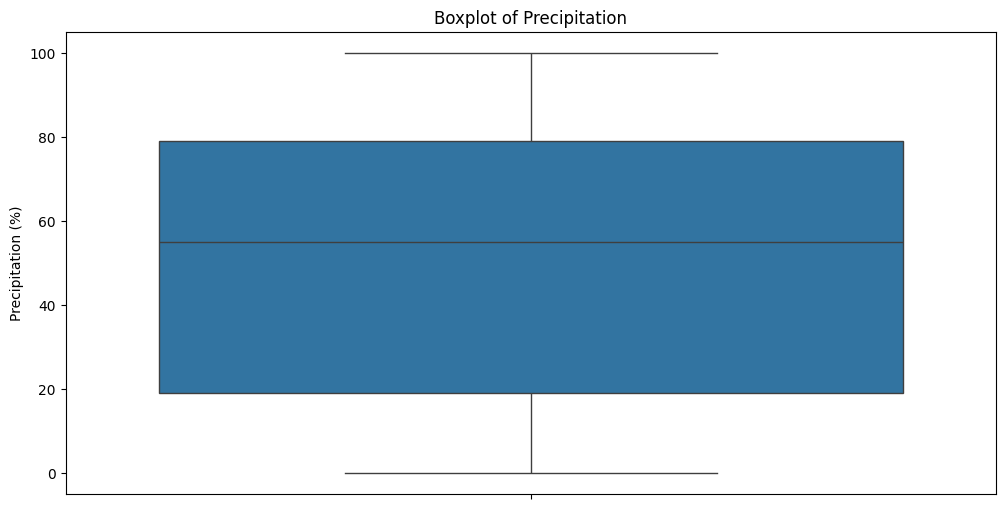

In [159]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df['Precipitation (%)'])
plt.title("Boxplot of Precipitation")
plt.show()

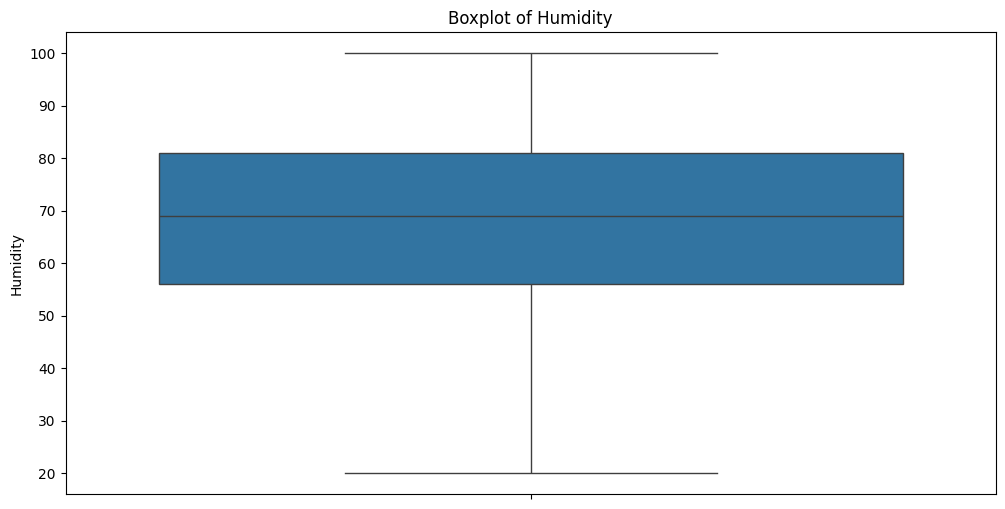

In [160]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df['Humidity'])
plt.title("Boxplot of Humidity")
plt.show()

In [161]:
cat_cols = df.select_dtypes(include='object').columns

encoding_maps = {}

for col in categorical_cols:
    df[col], uniques = pd.factorize(df[col])
    encoding_maps[col] = dict(enumerate(uniques))

encoding_maps

{'Cloud Cover': {0: 'partly cloudy', 1: 'clear', 2: 'overcast', 3: 'cloudy'},
 'Season': {0: 'Winter', 1: 'Spring', 2: 'Summer', 3: 'Autumn'},
 'Location': {0: 'inland', 1: 'mountain', 2: 'coastal'},
 'Weather Type': {0: 'Rainy', 1: 'Cloudy', 2: 'Sunny', 3: 'Snowy'}}

In [162]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,0,1010.82,2,0,3.5,0,0
1,39.0,96,8.5,71.0,0,1011.43,7,1,10.0,0,1
2,30.0,64,7.0,16.0,1,1018.72,5,1,5.5,1,2
3,38.0,83,1.5,82.0,1,1026.25,7,1,1.0,2,2
4,27.0,74,17.0,66.0,2,990.67,1,0,2.5,1,0


In [163]:
df.tail()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
13195,10.0,74,14.5,71.0,2,1003.15,1,2,1.0,1,0
13196,-1.0,76,3.5,23.0,3,1067.23,1,0,6.0,2,3
13197,30.0,77,5.5,28.0,2,1012.69,3,3,9.0,2,1
13198,3.0,76,10.0,94.0,2,984.27,0,0,2.0,0,3
13199,-5.0,38,0.0,92.0,2,1015.37,5,3,10.0,1,0


In [164]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
count,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000
mean,18.613074,67.100136,9.394577,51.207562,1.181126,1005.814698,3.824882,1.139470,5.532244,0.908435,1.502123
std,16.672864,19.383613,6.360919,31.019456,0.951368,38.134520,3.746314,1.160704,3.377035,0.791030,1.118399
min,-24.000000,20.000000,0.000000,0.000000,0.000000,800.120000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,56.000000,5.000000,19.000000,0.000000,994.695000,1.000000,0.000000,3.000000,0.000000,1.000000
50%,21.000000,69.000000,8.500000,55.000000,1.000000,1007.660000,2.000000,1.000000,5.000000,1.000000,2.000000
75%,30.000000,81.000000,13.000000,79.000000,2.000000,1016.825000,6.000000,2.000000,7.500000,2.000000,3.000000
max,109.000000,100.000000,48.500000,100.000000,3.000000,1199.210000,14.000000,3.000000,20.000000,2.000000,3.000000


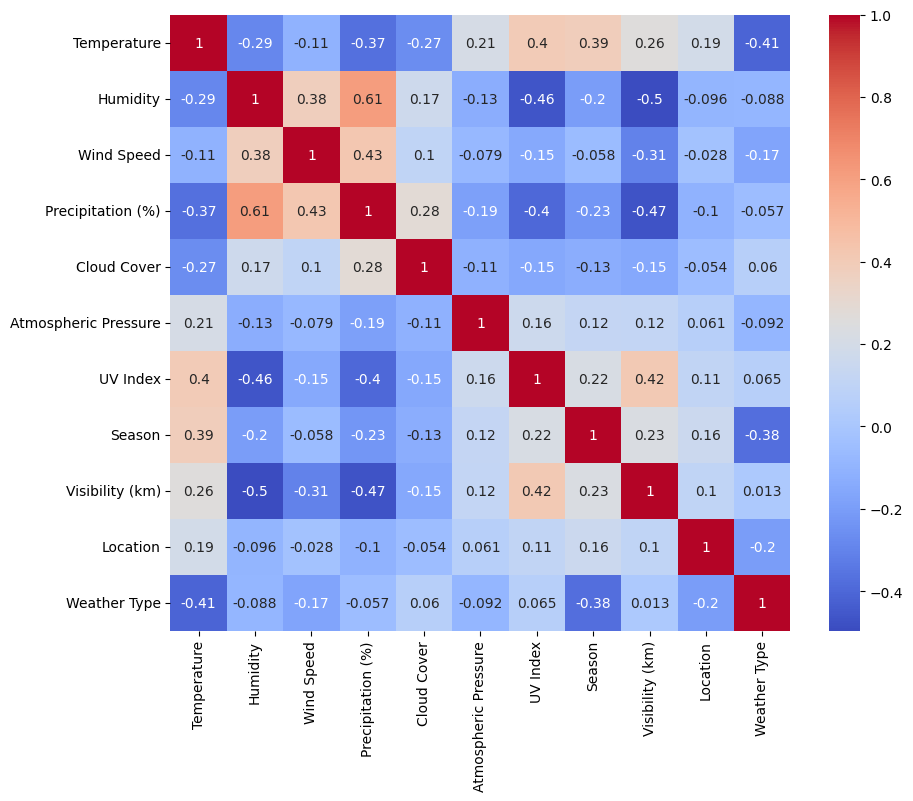

In [ ]:
correlation = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

In [166]:
correlation['Weather Type'].sort_values(ascending=False)

Weather Type            1.000000
UV Index                0.064718
Cloud Cover             0.059762
Visibility (km)         0.012831
Precipitation (%)      -0.056514
Humidity               -0.087636
Atmospheric Pressure   -0.092383
Wind Speed             -0.174416
Location               -0.203128
Season                 -0.377961
Temperature            -0.409699
Name: Weather Type, dtype: float64

In [167]:
X = df.drop('Weather Type', axis=1)
y = df['Weather Type']

In [168]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [169]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [170]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

knn

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [171]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

target_names = list(encoding_maps['Weather Type'].values())
print(f"\nModel Accuracy: {accuracy}")
print(classification_report(y_test, y_pred, target_names=target_names))


Model Accuracy: 0.8934721665999199
              precision    recall  f1-score   support

       Rainy       0.84      0.90      0.87       623
      Cloudy       0.87      0.87      0.87       623
       Sunny       0.94      0.88      0.91       625
       Snowy       0.94      0.92      0.93       626

    accuracy                           0.89      2497
   macro avg       0.90      0.89      0.89      2497
weighted avg       0.90      0.89      0.89      2497



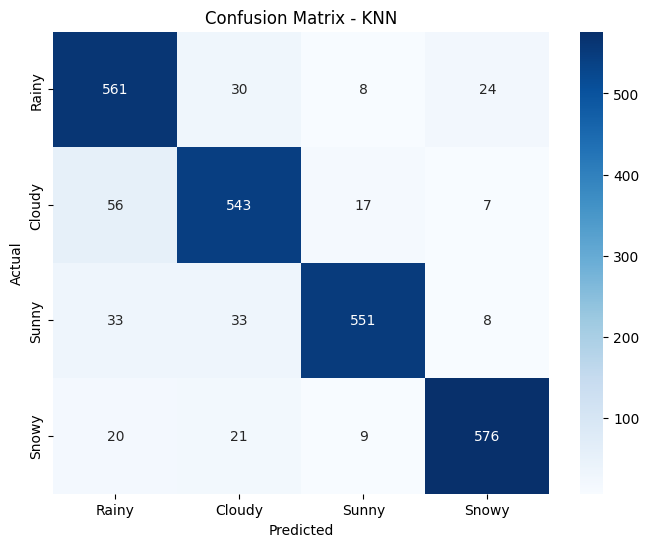

In [172]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()

In [173]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

target_names = list(encoding_maps['Weather Type'].values())

print(f"\nModel Accuracy: {accuracy}")
print(classification_report(y_test, y_pred, target_names = target_names))


Model Accuracy: 0.867440929114938
              precision    recall  f1-score   support

       Rainy       0.83      0.85      0.84       623
      Cloudy       0.87      0.82      0.85       623
       Sunny       0.88      0.86      0.87       625
       Snowy       0.88      0.93      0.91       626

    accuracy                           0.87      2497
   macro avg       0.87      0.87      0.87      2497
weighted avg       0.87      0.87      0.87      2497



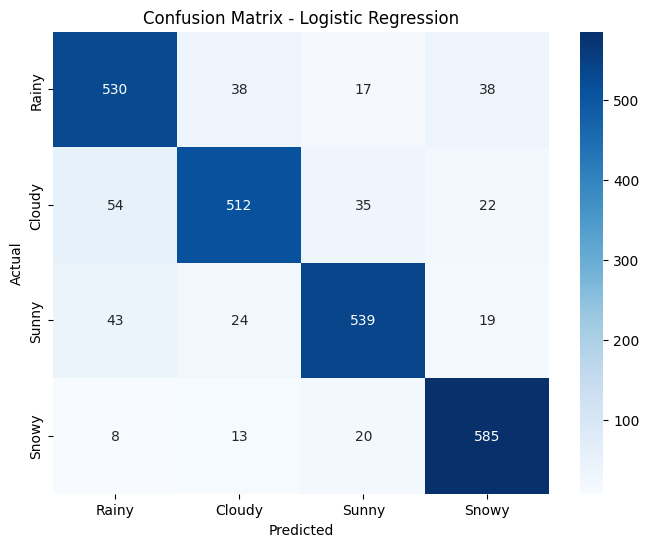

In [176]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [179]:
new_df = pd.DataFrame([
    [32.0, 40, 12.0, 5.0, 1, 1012.5, 9, 2, 10.0, 2], # Sunny scenario
    [-10.0, 85, 20.0, 60.0, 2, 995.0, 0, 0, 2.0, 1], # Snowy scenario
    [15.0, 90, 15.0, 85.0, 2, 1002.0, 1, 3, 3.0, 0], # Rainy scenario
    [20.0, 70, 5.0, 20.0, 3, 1010.0, 3, 1, 6.0, 0]   # Cloudy scenario
])

new_data_scaled = scaler.transform(new_df)

predictions = knn.predict(new_data_scaled)

weather_map = encoding_maps['Weather Type']

print("--- Model Prediction Results ---")
for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: Predicted Weather is -> {weather_map[pred]}")

--- Model Prediction Results ---
Sample 1: Predicted Weather is -> Sunny
Sample 2: Predicted Weather is -> Snowy
Sample 3: Predicted Weather is -> Rainy
Sample 4: Predicted Weather is -> Cloudy


C:\Users\SAAD MOHAMMED\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
